In [5]:
#########################
# Include Headers
#########################

using LinearAlgebra
using HDF5
using Arpack
using CairoMakie
using StatsBase

include("../header/.src/circuit/brickwall.jl")
include("../header/.src/circuit/hiesenberg.jl")
#include("../header/.src/circuit/time-crystals.jl")
include("../header/.src/hdf5/hdf5Mods.jl")
include("../header/.src/plotmods/colorschemes_mods.jl")

include("../header/.src/functions/eigenstatistics.jl")
include("../header/.src/functions/histgram.jl")

include("../header/.src/random_matrices/random_matrices.jl")
include("../header/.src/measurements/projectors.jl")
include("../header/.src/info_lattice/info_lattice.jl")
include("../header/.src/lazadires_diagram/lazadires_diagram.jl")


LazadiresDiagramPlot (generic function with 1 method)

In [6]:
#### attrs-author

tun_par=collect(0.0:0.1:5.0)
Xind=length(tun_par)
ord_par=fill(0.0, Xind)

L=8
itr=1

file=h5open("../data/hiesenberg_transition_ordpar.hdf5","r")

for i in 1:Xind
   theta=tun_par[i]
   ord_par[i]=LevelSpacingRatio(file["L$(L)/theta$(theta)/Itr$(itr)/eigvals"][:])
end
close(file)
ord_par

51-element Vector{Float64}:
 0.4359237744834346
 0.3744255507601961
 0.39086979250514325
 0.4222491618981919
 0.3826107143851771
 0.3933671974518774
 0.35785963409339816
 0.3567577159963202
 0.4028427101123961
 0.37791348687274223
 ⋮
 0.3973079217685587
 0.38221770069674077
 0.38237346612102346
 0.4382097724719593
 0.4612731074653559
 0.3715767766443378
 0.4060226187639127
 0.36933478725053154
 0.3505804848107289

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Ritam\.julia\packages\Makie\4JW9B\src\scenes.jl:264


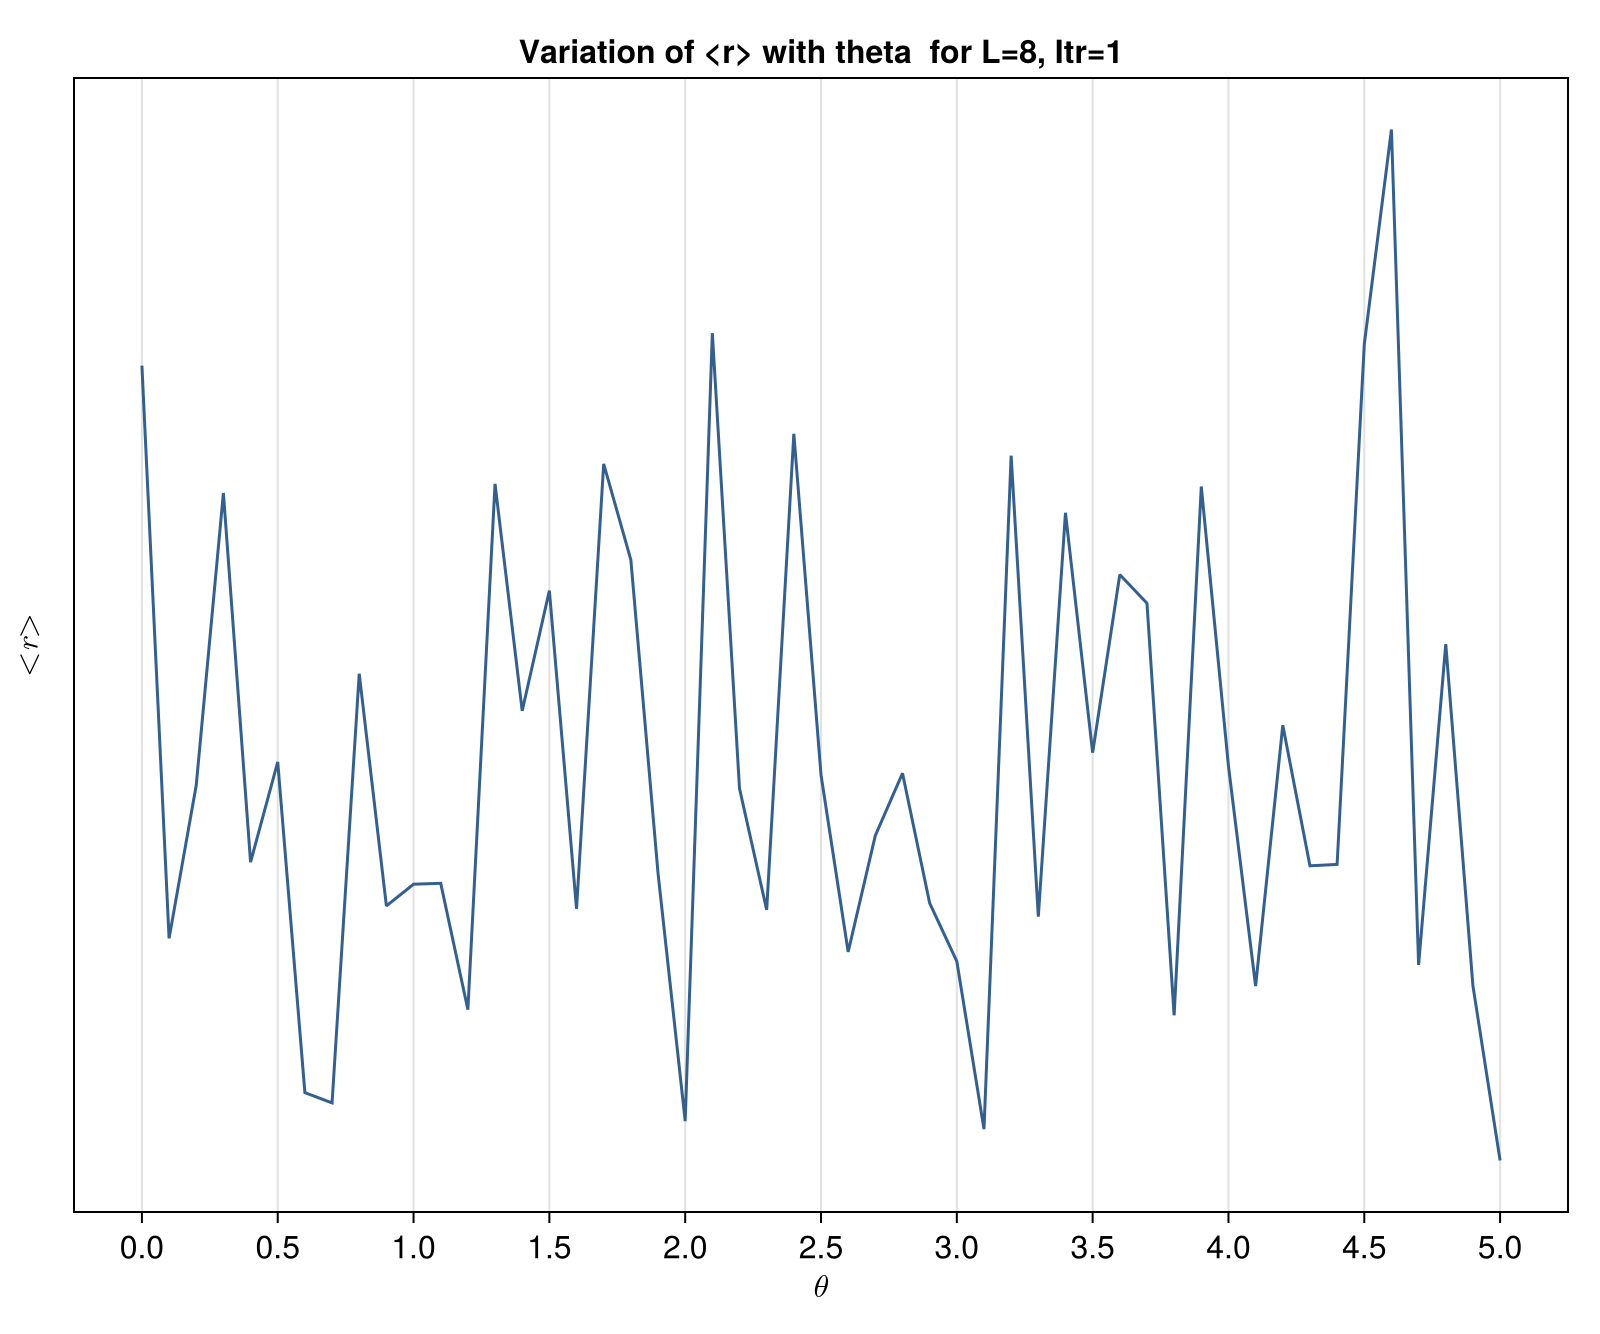

In [7]:
###############################
# Variation of <r> with theta  
###############################
    
# Desired aspect ratio
aspect_ratio = 6/5

# Set the figure width (for example, 800 pixels)
fig_width = 800
fig_height = fig_width / aspect_ratio
fig = Figure(resolution = (fig_width, fig_height), fontsize=16)


ax=Axis(fig[1,1],xlabel = L"$\theta$",          #Label for X  
ylabel = L"$<r>$",         #Label for Y
title = "Variation of <r> with theta  for L=8, Itr=1",      #Plot Title
xticks = (0.0:0.5:5.0),                #Xticks
yticks = (3.5:0.5:6.0) )



    xs = tun_par              
    ys = ord_par
    
    #The Heatmap
    CairoMakie.lines!(ax, xs, ys, color=viridis[35])

                                                             
   #Colorbar(fig[1,2],                        #Colorbar
   #              ticks = 0.0:0.1:1.0)            #Colorbar ticks
    
    fig
    